# Project 1
# Velazquez-Feliciano, Adrian
# DSC 680: Applied Data Science
# 04/05/2026

In [29]:
# Title: Customer Segmentation using KMeans
# Author: Vishakh Patel
# Date: 05 April 2026
# Modified By: Adrian Velazquez-Feliciano
# Description: This program loads, cleans, and analyzes customer data to perform
# customer segmentation using K-means clustering. It creates summary statistics,
# visualizations, and cluster profiles to support marketing recommendations.
#
# Code Attribution:
# This project was developed by Adrian Velazquez-Feliciano for DSC 680.
# The overall analysis, data preparation, feature engineering, clustering,
# interpretation, and written deliverables were completed for this assignment.
#
# Some ideas for workflow, clustering structure, and visualization were inspired by:
# - Course materials and examples from DSC 680
# - The Kaggle Customer Segmentation dataset page
# - General Python documentation for pandas, matplotlib, seaborn, and scikit-learn
# - Public educational video tutorials on customer segmentation and K-means clustering
#
# Specific outside inspiration referenced in the paper:
# - Dapat, V.: Customer segmentation clustering. Kaggle.
# - Vishakh, Patel: Customer Segmentation using KMeans. Kaggle
# - Data Science with Onur. Customer segmentation using machine learning
#   K-means clustering full Python data science project. YouTube. 19 July 2025.
#
# Any code adapted from examples was rewritten, modified, and integrated
# for the specific goals of this project.
# ===========================================

## Import Libraries, read data, and preview dataframe

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
from tqdm import tqdm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [31]:
# Confirm my working directory
import os
print(os.getcwd())

C:\Users\velaz\Desktop\JupyterProject
C:\Users\velaz\Desktop\JupyterProject


In [32]:
# Read the customer segmentation dataset into a pandas DataFrame
file_path = "customer_segmentation.csv"
df = pd.read_csv(file_path)

# Display the first five rows so the structure of the dataset can be reviewed
print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

# Data Cleaning and Feature Engineering

In [33]:
# Display dataset information to review column names, data types, and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [34]:
# Drop missing values
df = df.dropna()

In [35]:
# Investigate the values with string format for possible formatting

In [36]:
# Marital_Status values analysis
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [37]:
# Education values analysis
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [38]:
# DT_Customer values analysis
df['Dt_Customer'].value_counts()

Dt_Customer
31-08-2012    12
12-05-2014    11
12-09-2012    11
14-02-2013    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 662, dtype: int64

Dt_Customer
31-08-2012    12
12-05-2014    11
12-09-2012    11
14-02-2013    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 662, dtype: int64

In [39]:
# Convert the customer enrollment date column to datetime format
# This is necessary for time-based calculations later in the analysis
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst = True)
# Confirm changes
df.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   str           
 3   Marital_Status       2216 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[us]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   int64       

# Make some quick overview visuals

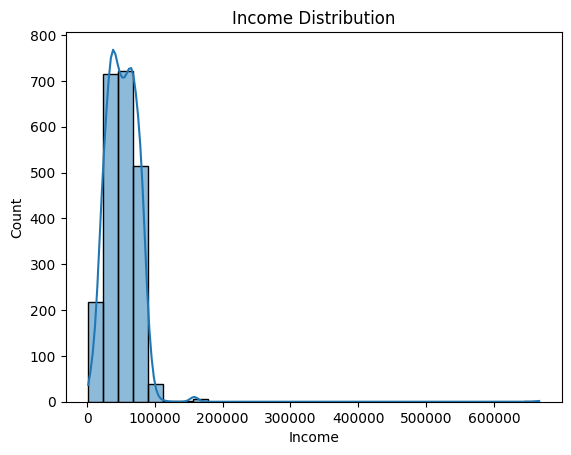

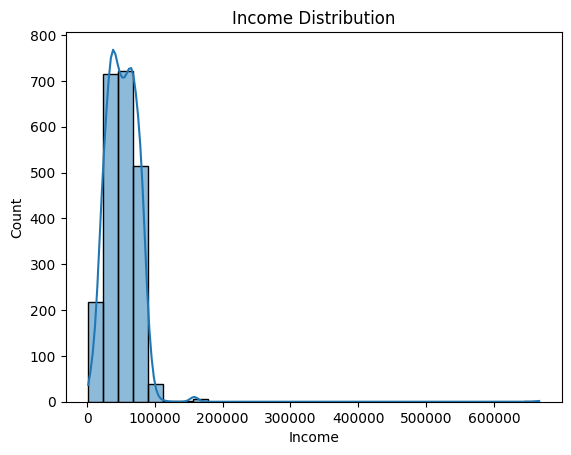

In [40]:
## Income Distribution
sns.histplot(df['Income'], bins = 30, kde=True)
plt.title('Income Distribution')
plt.show()

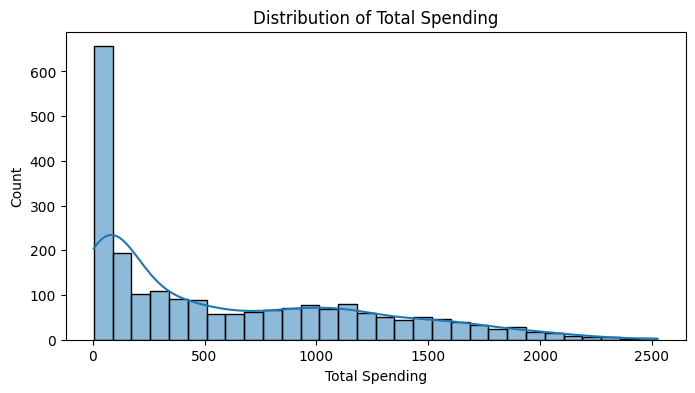

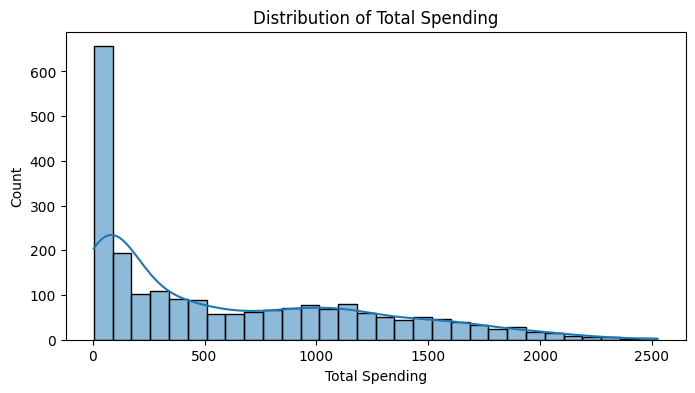

In [41]:
## Total Spending Distribution
spend_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]
df['Total_Spending'] = df[spend_cols].sum(axis=1)
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)
plt.figure(figsize=(8,4))
sns.histplot(df['Total_Spending'], bins=30, kde=True)
plt.title('Distribution of Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Count')
plt.show()


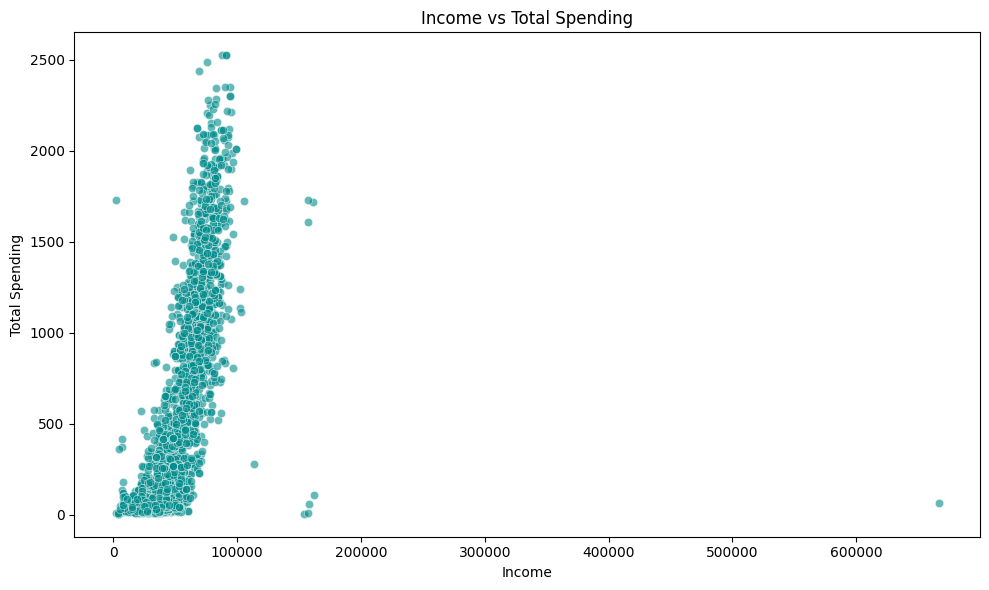

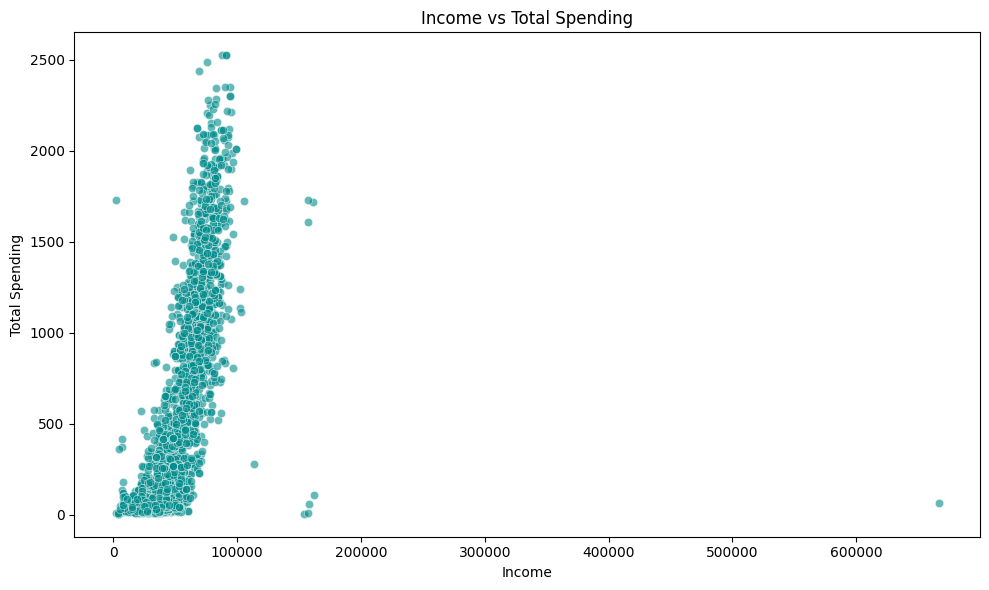

In [42]:
# Income vs Total Spending
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data= df,
    x="Income",
    y="Total_Spending",
    alpha=0.6,
    color="darkcyan"
)
plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count')

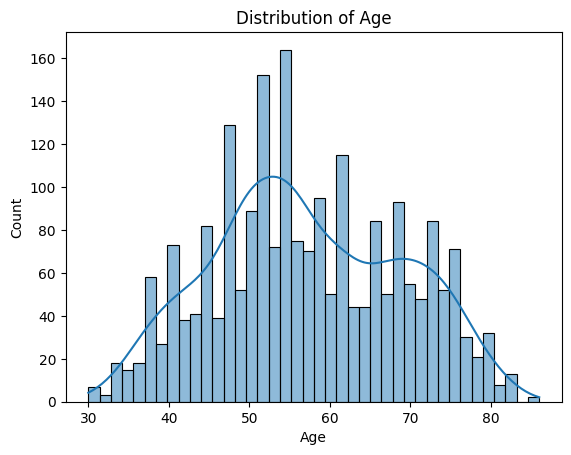

Text(0, 0.5, 'Count')

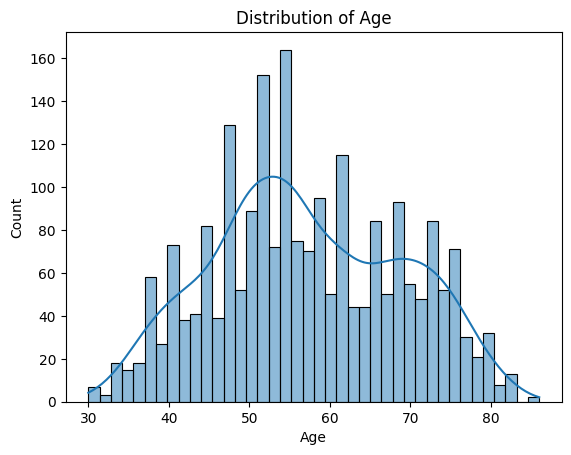

In [43]:
# Create an Age feature
df["Age"] = 2026 - df["Year_Birth"]
# Remove unrealistic ages to improve data quality before analysis
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)].copy()
# Plot the Age Distribution after removing unrealistic values
sns.histplot(df['Age'], bins=40, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

In [44]:
# Create a Total_Children feature by combining children and teenagers in the household
# This simplifies household composition into one variable
df["Total_Children"] = df['Kidhome'] + df['Teenhome']

In [45]:
# Group customers by assigned cluster and calculate average values
# This summary helps interpret the characteristics of each customer segment
summary_cols = [
    "Income",
    "Age",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumWebVisitsMonth",
    "Total_Children",
    "Response"
]
# Generate descriptive statistics for the selected variables
summary_stats = df[summary_cols].describe().round(2)
# Display the summary statistics table
print(summary_stats)

          Income      Age  Recency  Total_Spending  Total_Purchases  \
count    2213.00  2213.00  2213.00         2213.00          2213.00   
mean    52236.58    57.08    49.01          607.02            12.56   
std     25178.60    11.70    28.94          602.49             7.20   
min      1730.00    30.00     0.00            5.00             0.00   
25%     35246.00    49.00    24.00           69.00             6.00   
50%     51373.00    56.00    49.00          397.00            12.00   
75%     68487.00    67.00    74.00         1048.00            18.00   
max    666666.00    86.00    99.00         2525.00            32.00   

       NumWebVisitsMonth  Total_Children  Response  
count            2213.00         2213.00   2213.00  
mean                5.32            0.95      0.15  
std                 2.43            0.75      0.36  
min                 0.00            0.00      0.00  
25%                 3.00            0.00      0.00  
50%                 6.00            1.00  

# Clustering

In [46]:
# Select the features used for clustering
cluster_features = [
    "Income",
    "Recency",
    "Total_Spending",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]
# Create a separate DataFrame with only the clustering features
cluster_df = df[cluster_features].copy()

# Scale data

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

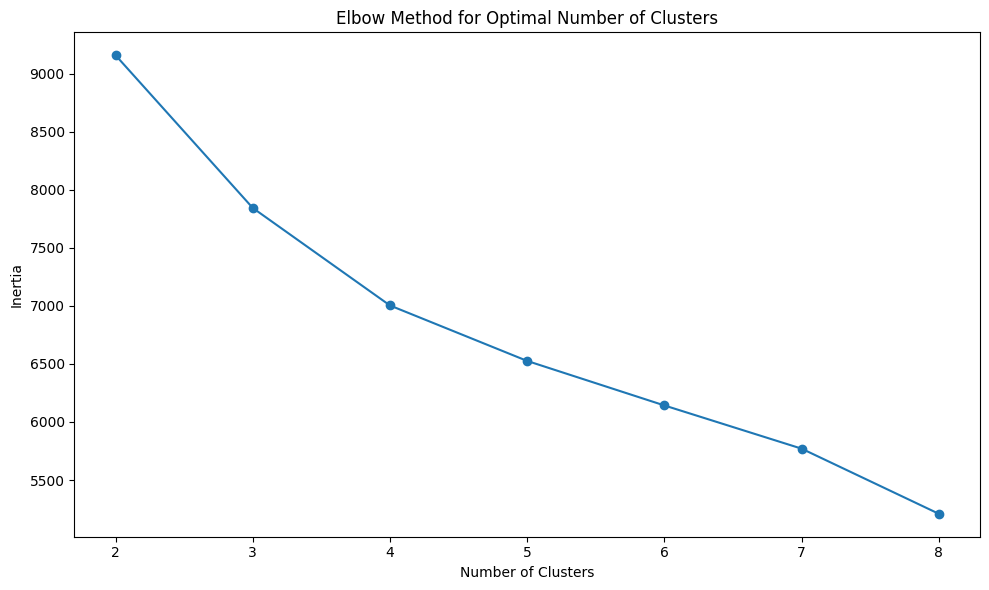

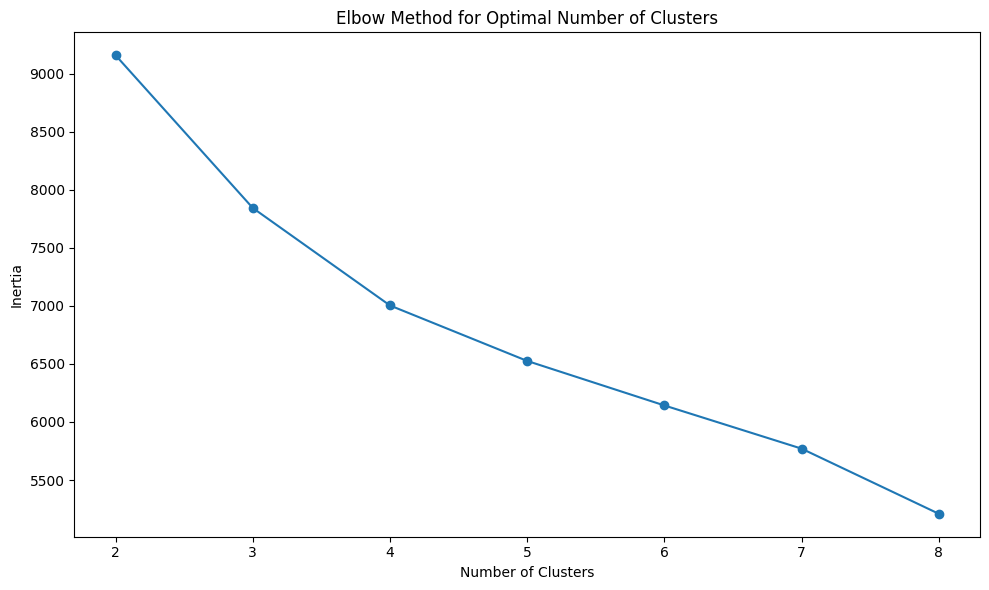

In [47]:
# Use elbow method to compare inertia across cluster counts
inertia_vals = []
cluster_range = range(2, 9)

for k in cluster_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(cluster_scaled)
    inertia_vals.append(kmeans_model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia_vals, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [48]:
# Compare silhouette scores for possible cluster counts
silhouette_vals = []
cluster_range = range(2, 9)

for k in cluster_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, labels)
    silhouette_vals.append(score)

silhouette_results = pd.DataFrame({
    "Clusters": list(cluster_range),
    "Silhouette_Score": silhouette_vals
})

print(silhouette_results)

   Clusters  Silhouette_Score
0         2          0.383526
1         3          0.307341
2         4          0.233066
3         5          0.222931
4         6          0.219361
5         7          0.219832
6         8          0.224236
   Clusters  Silhouette_Score
0         2          0.383526
1         3          0.307341
2         4          0.233066
3         5          0.222931
4         6          0.219361
5         7          0.219832
6         8          0.224236


In [49]:
# Fit final KMeans model
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(cluster_scaled)

# Check cluster counts
print(df["Cluster"].value_counts().sort_index())

Cluster
0    557
1    538
2    586
3    532
Name: count, dtype: int64
Cluster
0    557
1    538
2    586
3    532
Name: count, dtype: int64


In [50]:
# Profile the clusters using average values
cluster_profile = df.groupby("Cluster")[[
    "Income",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumWebVisitsMonth",
    "Response",
    "Total_Children",
    "Age"
]].mean().round(2)

print(cluster_profile)

           Income  Recency  Total_Spending  Total_Purchases  \
Cluster                                                       
0        36938.64    74.98          133.22             6.74   
1        78165.75    50.68         1341.26            18.96   
2        34818.09    24.17          121.08             6.37   
3        61218.34    47.48          895.84            19.02   

         NumWebVisitsMonth  Response  Total_Children    Age  
Cluster                                                      
0                     6.22      0.04            1.26  56.01  
1                     2.39      0.24            0.27  58.56  
2                     6.64      0.16            1.21  54.61  
3                     5.89      0.17            1.01  59.43  
           Income  Recency  Total_Spending  Total_Purchases  \
Cluster                                                       
0        36938.64    74.98          133.22             6.74   
1        78165.75    50.68         1341.26            18.96 

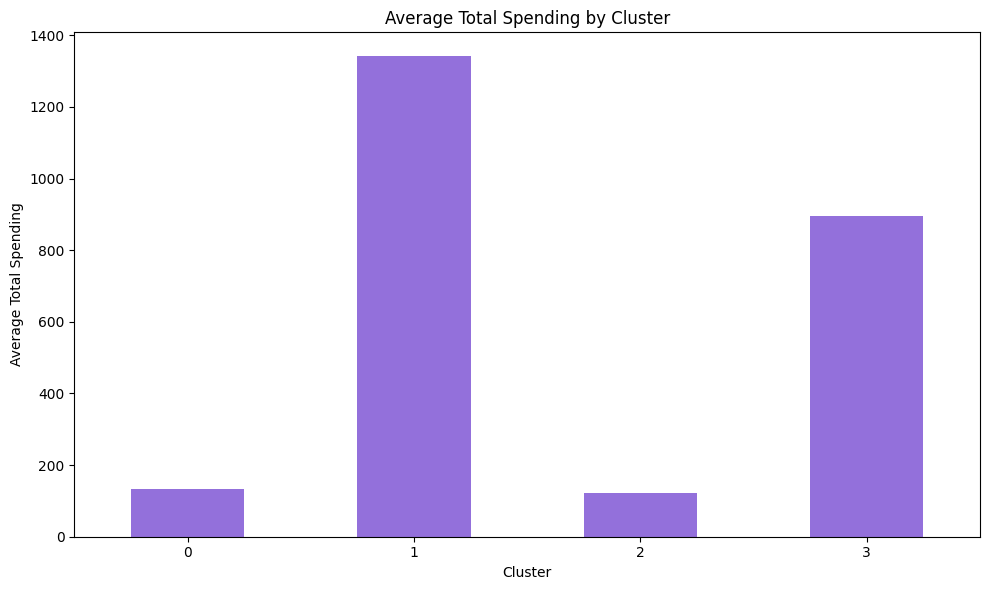

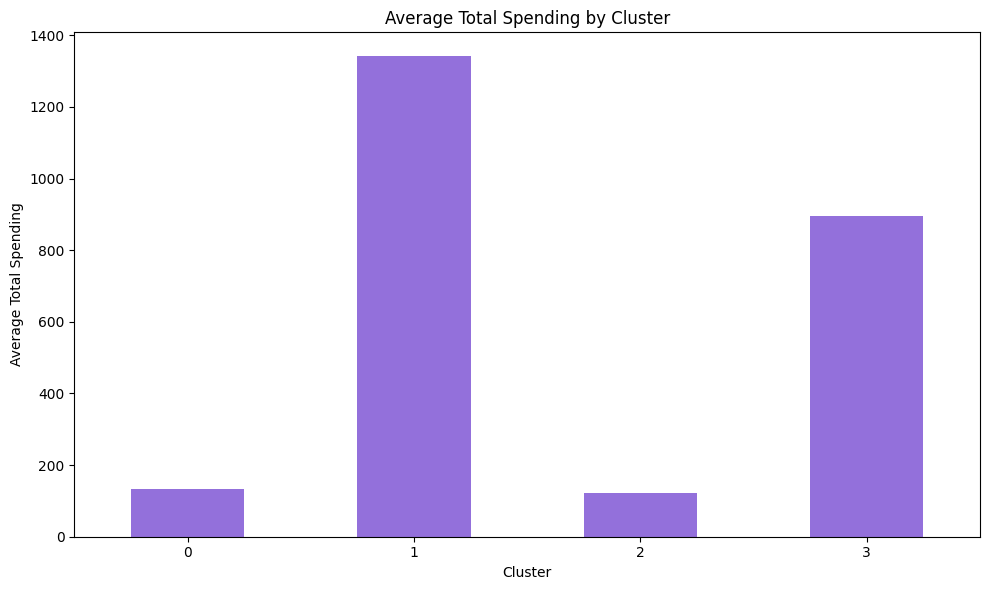

In [51]:
# Plot: Average total spending by cluster
plt.figure(figsize=(10, 6))
cluster_profile["Total_Spending"].plot(kind="bar", color="mediumpurple")
plt.title("Average Total Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

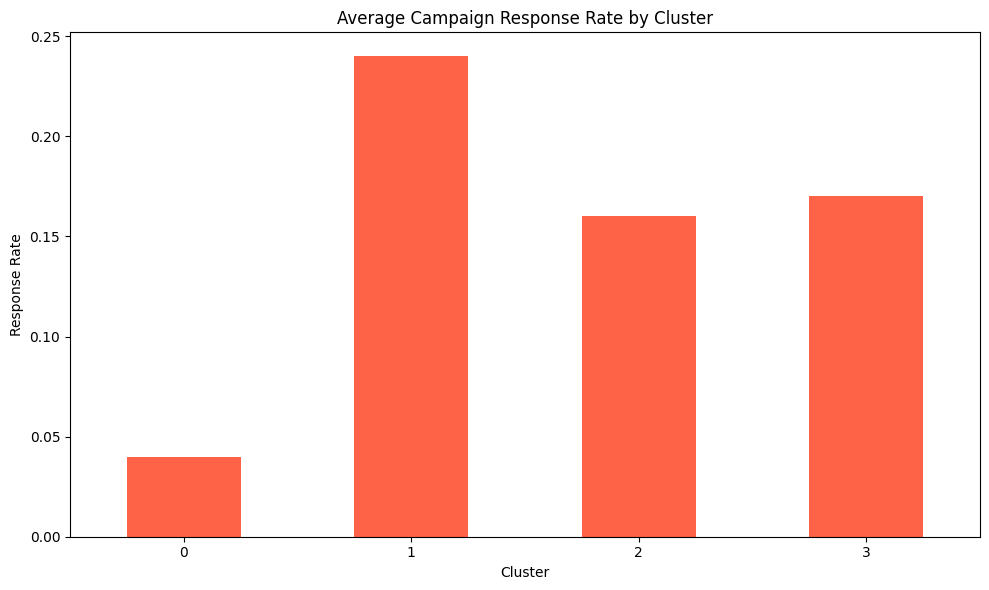

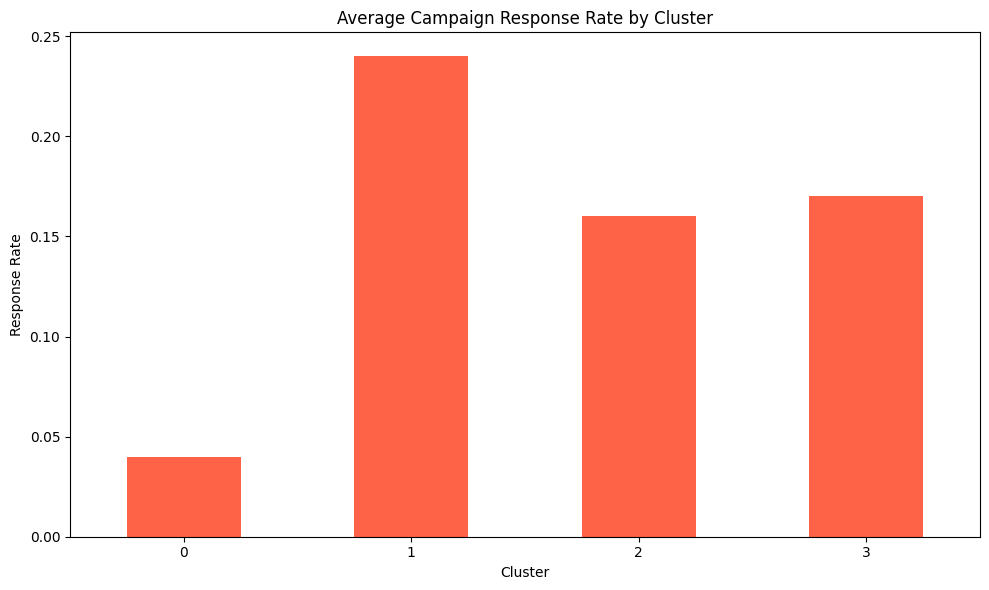

In [52]:
# Plot: Campaign response rate by cluster
plt.figure(figsize=(10, 6))
cluster_profile["Response"].plot(kind="bar", color="tomato")
plt.title("Average Campaign Response Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Response Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

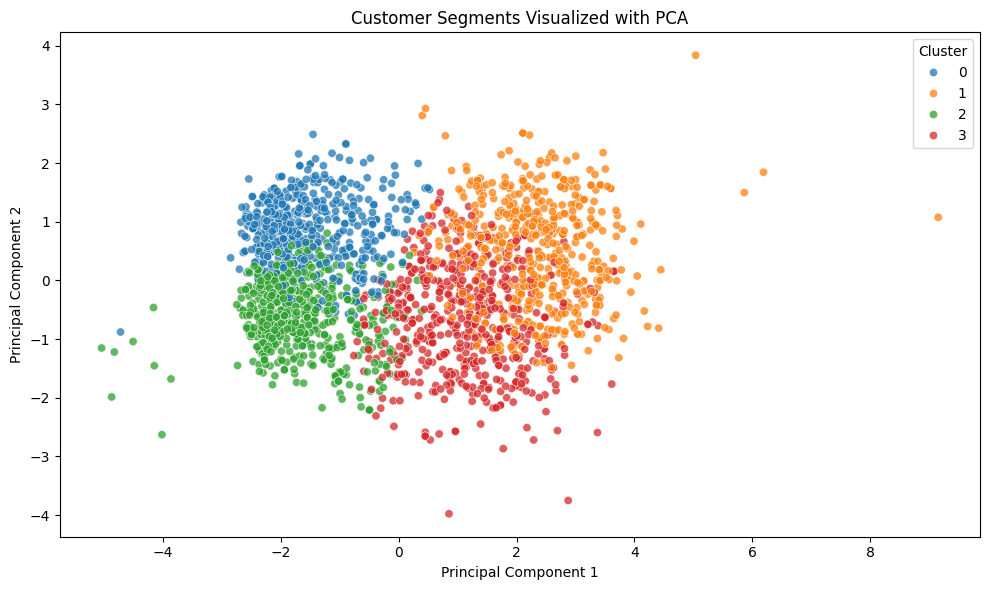

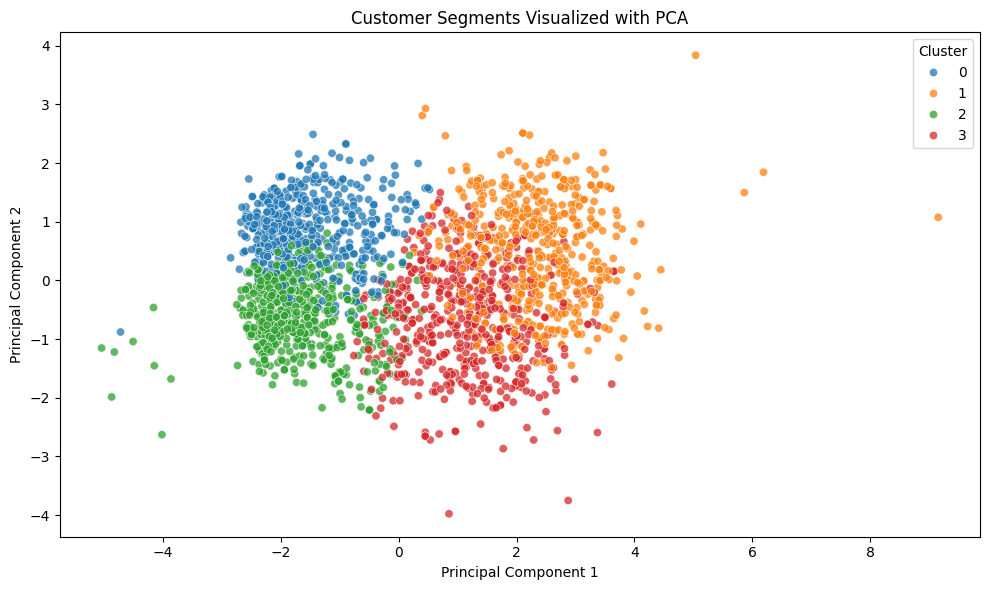

In [53]:
# Use PCA to reduce the clustering features to 2 dimensions for visualization
pca_model = PCA(n_components=2)
pca_components = pca_model.fit_transform(cluster_scaled)

pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"].values

# Plot: PCA projection of customer clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.75
)
plt.title("Customer Segments Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [54]:
# Examine spending by product category across clusters
category_profile = df.groupby("Cluster")[spend_cols].mean().round(2)
print(category_profile)

         MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                          
0           60.91       6.30            30.44             9.14   
1          607.65      60.06           446.35            89.91   
2           57.96       5.48            26.10             8.08   
3          527.25      36.13           182.52            47.15   

         MntSweetProducts  MntGoldProds  
Cluster                                  
0                    6.75         19.68  
1                   62.50         74.79  
2                    5.09         18.36  
3                   36.57         66.21  
         MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                          
0           60.91       6.30            30.44             9.14   
1          607.65      60.06           446.35            89.91   
2           57.96       5.48            26.10             8.08   
3          527.25    

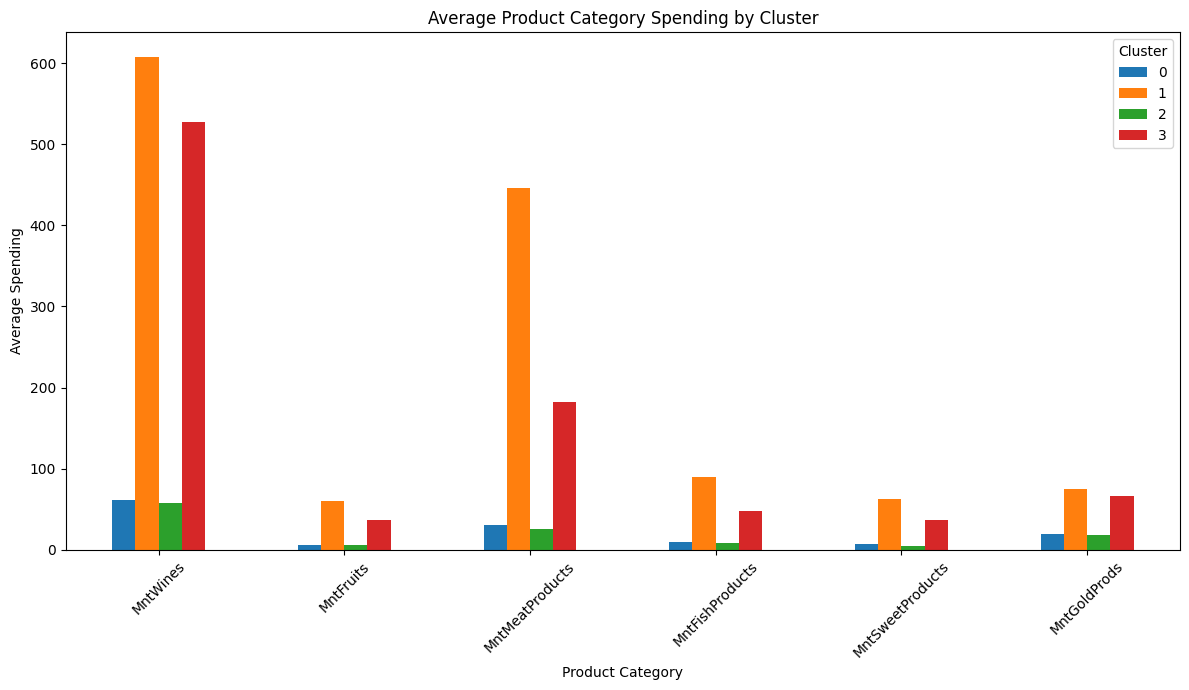

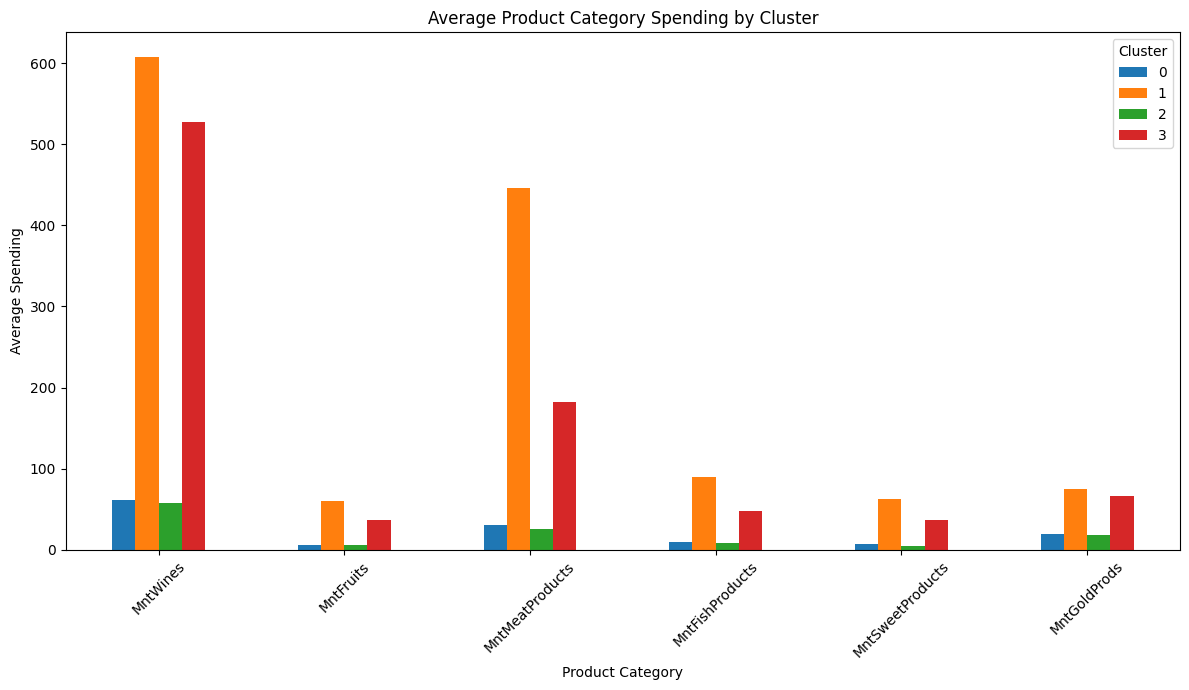

In [55]:
# Plot: Product spending profile by cluster
category_profile.T.plot(kind="bar", figsize=(12, 7))
plt.title("Average Product Category Spending by Cluster")
plt.xlabel("Product Category")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
# Save cleaned dataset with cluster labels for appendix or export
df.to_csv("customer_segmentation_clustered_output.csv", index=False)

# Save cluster profile table
cluster_profile.to_csv("cluster_profile_summary.csv")

# Save category profile table
category_profile.to_csv("cluster_category_profile.csv")

print("Files saved successfully.")
print("customer_segmentation_clustered_output.csv")
print("cluster_profile_summary.csv")
print("cluster_category_profile.csv")

Files saved successfully.
customer_segmentation_clustered_output.csv
cluster_profile_summary.csv
cluster_category_profile.csv
Files saved successfully.
customer_segmentation_clustered_output.csv
cluster_profile_summary.csv
cluster_category_profile.csv
